# Refinement, failure handling, and pipeline timing

This notebook summarises saved software evidence. The eight refinement cases evaluate feedback interpretation only; JUnit cases check selective routing and preservation with mocked providers. Neither is a human assessment of refined-output quality. Completed live pipeline rows provide the end-to-end latency measurements.


In [1]:
from pathlib import Path
import json
import xml.etree.ElementTree as ET
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display


def find_eval_dir():
    for base in (Path.cwd(), *Path.cwd().parents):
        candidate = base / "eval"
        if (candidate / "comparison" / "refinement" / "refinement_summary.json").is_file():
            return candidate
    raise FileNotFoundError("Run from the repository or its eval/notebook directory")


EVAL = find_eval_dir()
REFINEMENT = EVAL / "comparison" / "refinement"
PIPELINE = EVAL / "comparison" / "pipeline"
print(EVAL)


d:\CM3070_Brandbit\eval


### 1. Feedback interpretation cases

These eight frozen BAD cases check interpreted edits, clarification, and modality neutrality. They do not regenerate specialists or measure improvement in fragrance or music quality.


In [2]:
summary = json.loads((REFINEMENT / "refinement_summary.json").read_text(encoding="utf-8"))
cases = pd.read_csv(REFINEMENT / "refinement_results.csv", encoding="utf-8-sig")
assert len(cases) == summary["n_cases"]
assert cases["case_id"].is_unique
metrics = pd.Series({
    "cases": len(cases),
    "correct decisions": int(cases["correct_decision"].sum()),
    "no-leak cases": int(cases["no_leak"].sum()),
    "median interpretation latency (ms)": cases["interpret_latency_ms"].median(),
}, name="value")
display(metrics.to_frame())
display(cases[["case_id", "expected_behavior", "changed_fields", "correct_decision", "check_reason", "interpret_latency_ms"]])
print("Scope:", summary["scope"])


,value
cases,8.0
correct decisions,8.0
no-leak cases,8.0
median interpretation latency (ms),2029.0


,case_id,expected_behavior,changed_fields,correct_decision,check_reason,interpret_latency_ms
0,R01,energy_up,energy,1,energy low → moderate,5089
1,R02,warmer,color_temperature,1,color_temperature cool → warm,2015
2,R03,energy_down,energy,1,energy high → low,2047
3,R04,calmer,mood; narrative,1,Mood/energy moved calmer.,3366
4,R05,energy_up,energy,1,energy moderate → high,1838
5,R06,clarify,NaN,1,Clarified without mutation.,1631
6,R07,clarify,NaN,1,Clarified without mutation.,1741
7,R08,no_leak,NaN,1,No specialist fields leaked onto the BAD.,2043


Scope: interpret_and_refine only — frozen BADs, no specialist regen, no overwrite of eval/result execution records


## 2. Selective refinement and injected failures


In [3]:
root = ET.parse(REFINEMENT / "selective_refinement_junit.xml").getroot()
suites = root.findall(".//testsuite")
if root.tag == "testsuite":
    suites = [root]
assert suites, "No JUnit test suite found"
assert sum(int(s.get("failures", 0)) + int(s.get("errors", 0)) for s in suites) == 0
assert sum(int(s.get("skipped", 0)) for s in suites) == 0
tests = pd.DataFrame([
    {"test": node.get("name"), "module": node.get("classname", "").split(".")[-1],
     "status": "passed" if not list(node) else "other"}
    for node in root.findall(".//testcase")
])
assert len(tests) == sum(int(s.get("tests", 0)) for s in suites)
assert tests["status"].eq("passed").all()
display(tests.groupby("module")["status"].agg(["count"]))
print(f"Offline tests passed: {len(tests)}/{len(tests)}")
focus = tests[tests["module"].eq("test_selective_refinement_evaluation")]
display(focus[["test", "status"]])


,count
module,
test_congruence_regen_loop,8
test_refinement,9
test_selective_refinement_evaluation,7


Offline tests passed: 24/24


,test,status
0,test_selected_outputs_change_and_retained_file...,passed
1,test_selected_outputs_change_and_retained_file...,passed
2,test_selected_outputs_change_and_retained_file...,passed
3,test_provider_failure_does_not_replace_saved_r...,passed
4,test_provider_failure_does_not_replace_saved_r...,passed
5,test_provider_failure_does_not_replace_saved_r...,passed
6,test_provider_failure_does_not_replace_saved_r...,passed


In [4]:
failure_tests = focus.loc[focus["test"].str.startswith("test_provider_failure_does_not_replace_saved_run")].copy()
failure_tests["injected_stage"] = failure_tests["test"].str.extract(r"\[(specialist|judge|audio|rationale)\]")
assert set(failure_tests["injected_stage"]) == {"specialist", "judge", "audio", "rationale"}
failure_tests["checked_outcome"] = "saved execution hash unchanged after injected failure"
display(failure_tests[["injected_stage", "checked_outcome", "status"]].sort_values("injected_stage"))


,injected_stage,checked_outcome,status
5,audio,saved execution hash unchanged after injected ...,passed
4,judge,saved execution hash unchanged after injected ...,passed
6,rationale,saved execution hash unchanged after injected ...,passed
3,specialist,saved execution hash unchanged after injected ...,passed


### 3. Saved end-to-end runs and failures

In [5]:
paths = sorted(PIPELINE.glob("latency_*.csv"))
if not paths:
    print("No pipeline timing CSVs yet. Run backend/scripts/evaluate_pipeline_latency.py first.")
    runs = pd.DataFrame()
else:
    runs = pd.concat((pd.read_csv(path).assign(source_file=path.name) for path in paths), ignore_index=True)
    runs["total_ms"] = pd.to_numeric(runs["total_ms"], errors="coerce")
    display(runs[["source_file", "image", "mode", "repeat", "status", "execution_id",
                  "total_ms", "congruence_accepted", "regen_count", "error"]])


,source_file,image,mode,repeat,status,execution_id,total_ms,congruence_accepted,regen_count,error
0,latency_20260927T071343Z.csv,1.png,bad,1,completed,1_001 (BAD),91262,True,0,NaN
1,latency_20260927T071343Z.csv,1.png,bad,2,completed,1_001 (BAD),84662,True,0,NaN


Successful complete runs: 2 | failed/incomplete runs: 0


,,repeats,median_ms,min_ms,max_ms
image,mode,,,,
1.png,bad,2,87962.0,84662,91262


,count,median,min,max
stage,,,,
audio,2,38808.5,38473,39144
clip,2,7084.5,6783,7386
congruence,2,3137.5,2912,3363
descriptor,2,3539.0,2272,4806
fragrance,2,11561.5,9398,13725
music,2,7835.5,7157,8514
rationale,2,7628.5,6761,8496
save,2,5.0,5,5
specialists,2,69207.0,65780,72634


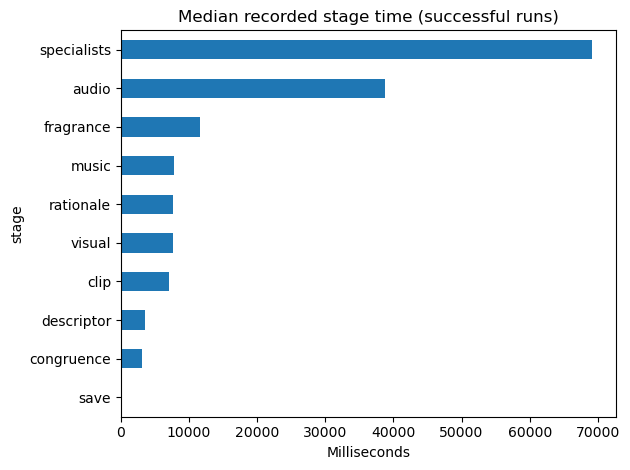

In [6]:
if runs.empty:
    successful = pd.DataFrame()
    failed = pd.DataFrame()
else:
    successful = runs.loc[runs["status"].isin(["completed", "ok"])].copy()
    failed = runs.loc[~runs["status"].isin(["completed", "ok"])].copy()

print("Successful complete runs:", len(successful), "| failed/incomplete runs:", len(failed))
if not failed.empty:
    display(failed[["source_file", "image", "total_ms", "stage_ms_json", "error"]])
if successful.empty:
    print("No successful end-to-end latency estimate can be reported yet.")
else:
    display(successful.groupby(["image", "mode"])["total_ms"].agg(
        repeats="count", median_ms="median", min_ms="min", max_ms="max"
    ).round(1))
    stage_rows = []
    for _, run in successful.iterrows():
        stages = json.loads(run["stage_ms_json"]) if pd.notna(run["stage_ms_json"]) else {}
        for stage, durations in stages.items():
            stage_rows.append({"source_file": run["source_file"], "stage": stage,
                               "duration_ms": sum(durations) if isinstance(durations, list) else durations})
    if stage_rows:
        stage_df = pd.DataFrame(stage_rows)
        display(stage_df.groupby("stage")["duration_ms"].agg(["count", "median", "min", "max"]).round(1))
        stage_df.groupby("stage")["duration_ms"].median().sort_values().plot.barh(
            title="Median recorded stage time (successful runs)", xlabel="Milliseconds"
        )
        plt.tight_layout()
        plt.show()
